## Modeling & Evaluation
Objective: Train and evaluate machine learning models to predict customer churn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
X=pd.read_csv("../Dataset/X_processed.csv")
y=pd.read_csv("../Dataset/y.csv").squeeze()


In [3]:
X.head()

,SeniorCitizen,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_6-12,tenure_bucket_12-24,tenure_bucket_24-48,tenure_bucket_49+
0,0,27.43,True,True,True,False,False,True,False,True,...,False,False,True,True,False,False,False,False,False,False
1,0,38.28,False,False,False,True,True,False,False,False,...,False,True,False,False,True,False,False,False,True,False
2,0,106.44,True,False,False,True,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
3,1,92.49,True,False,True,True,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
4,1,19.63,True,True,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


In [4]:
y

0      1
1      1
2      1
3      0
4      1
      ..
295    0
296    1
297    1
298    0
299    1
Name: churn_flag, Length: 300, dtype: int64

Splitting the dataset into train and test dataset

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Baseline model

In [6]:
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_pred=log_reg.predict(X_test)
y_prob=log_reg.predict_proba(X_test)[:,1]

In [8]:
print(classification_report(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.48      0.69      0.56        32
           1       0.29      0.14      0.19        28

    accuracy                           0.43        60
   macro avg       0.38      0.42      0.38        60
weighted avg       0.39      0.43      0.39        60

ROC AUC: 0.4296875


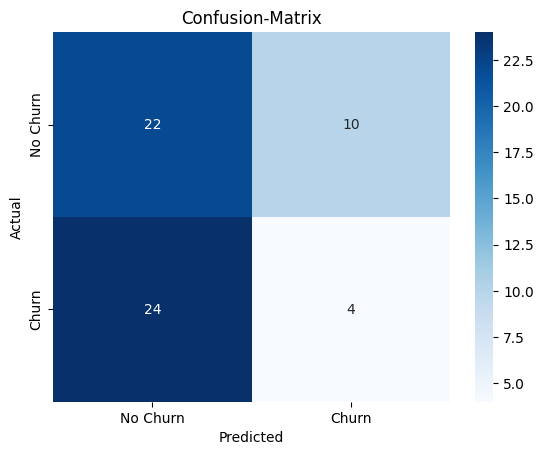

In [9]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'],
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion-Matrix")
plt.show()

## Baseline Model Evaluation (Logistic Regression)

The logistic regression model was used as a baseline to evaluate the predictive power of the engineered features.

### Observations:
- The model achieves low recall for the churn class, indicating that most churned customers are not being correctly identified.
- Precision for churn is also low, suggesting a high number of false positives.
- The ROC-AUC score is below 0.5, indicating that the model struggles to distinguish between churned and non-churned customers.
- This suggests that the relationship between features and churn is likely non-linear and not well captured by a linear model.

### Conclusion:
Logistic Regression serves as a useful baseline; however, its performance is insufficient for effective churn prediction. This motivates the use of more expressive, non-linear models such as tree-based classifiers.

The next step is to train and evaluate a Random Forest model to improve performance.
